In [1]:
from simulation.simulator import *
import numpy as np
from constants import *
from tqdm import tqdm
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 200})


In [2]:
N_r_vals = [10, 20, 50, 100, 200, 400, 1000, 2000]
C_N_results, C_F_results, C_NI_results, C_I_results = [], [], [], []

phys = PhysicsConstants()
D_N = D_N_from_dim(phys)
P_N = P_N_from_dim(phys)
alpha = alpha_from_dim(phys)

In [3]:
for N_r in tqdm(N_r_vals):
    params = SimulationParameters(Nr=N_r)
    r, t, C_N, C_F, C_NI, C_I = forward_solver(P_N, D_N, alpha, phys, params)
    C_N_results.append(C_N)
    C_F_results.append(C_F)
    C_NI_results.append(C_NI)
    C_I_results.append(C_I)


100%|██████████| 8/8 [07:24<00:00, 55.58s/it] 


In [4]:
def format_sci(number, precision=2):
    sci_str = f"{number:.{precision}e}"
    
    base, exponent = sci_str.split("e")
    
    exponent_int = int(exponent)
    
    return rf"${base} \times 10^{{{exponent_int}}}$"


In [5]:
C_N_errs, C_F_errs, C_NI_errs, C_I_errs = [], [], [], []

norm_C_N = np.sum(C_N_results[-1]**2) / N_r_vals[-1]
norm_C_F = np.sum(C_F_results[-1]**2) / N_r_vals[-1]
norm_C_NI = np.sum(C_NI_results[-1]**2) / N_r_vals[-1]
norm_C_I = np.sum(C_I_results[-1]**2) / N_r_vals[-1]

for N_r, C_N, C_F, C_NI, C_I in zip(N_r_vals, C_N_results, C_F_results, C_NI_results, C_I_results):
    C_N_ref = C_N_results[-1][:,::(N_r_vals[-1] // N_r)]
    C_N_rel = (C_N - C_N_ref)**2 / norm_C_N
    C_N_errs.append(np.mean(C_N_rel) * 100)

    C_F_ref = C_F_results[-1][:,::(N_r_vals[-1] // N_r)]
    C_F_rel = (C_F - C_F_ref)**2 / norm_C_F
    C_F_errs.append(np.mean(C_F_rel) * 100)

    C_NI_ref = C_NI_results[-1][:,::(N_r_vals[-1] // N_r)]
    C_NI_rel = (C_NI - C_NI_ref)**2 / norm_C_NI
    C_NI_errs.append(np.mean(C_NI_rel) * 100)

    C_I_ref = C_I_results[-1][:,::(N_r_vals[-1] // N_r)]
    C_I_rel = (C_I - C_I_ref)**2 / norm_C_I
    C_I_errs.append(np.mean(C_I_rel) * 100)

def convergence_slope(N_r_vals, errors):
    N_r_vals = np.asarray(N_r_vals)
    errors = np.asarray(errors)

    mask = (errors > 0) & np.isfinite(errors)

    slope, intercept = np.polyfit(
        np.log(N_r_vals[mask]),
        np.log(errors[mask]),
        1
    )
    return -slope


p_CN = convergence_slope(N_r_vals, C_N_errs)
p_CF = convergence_slope(N_r_vals, C_F_errs)
p_NI = convergence_slope(N_r_vals, C_NI_errs)
p_I  = convergence_slope(N_r_vals, C_I_errs)


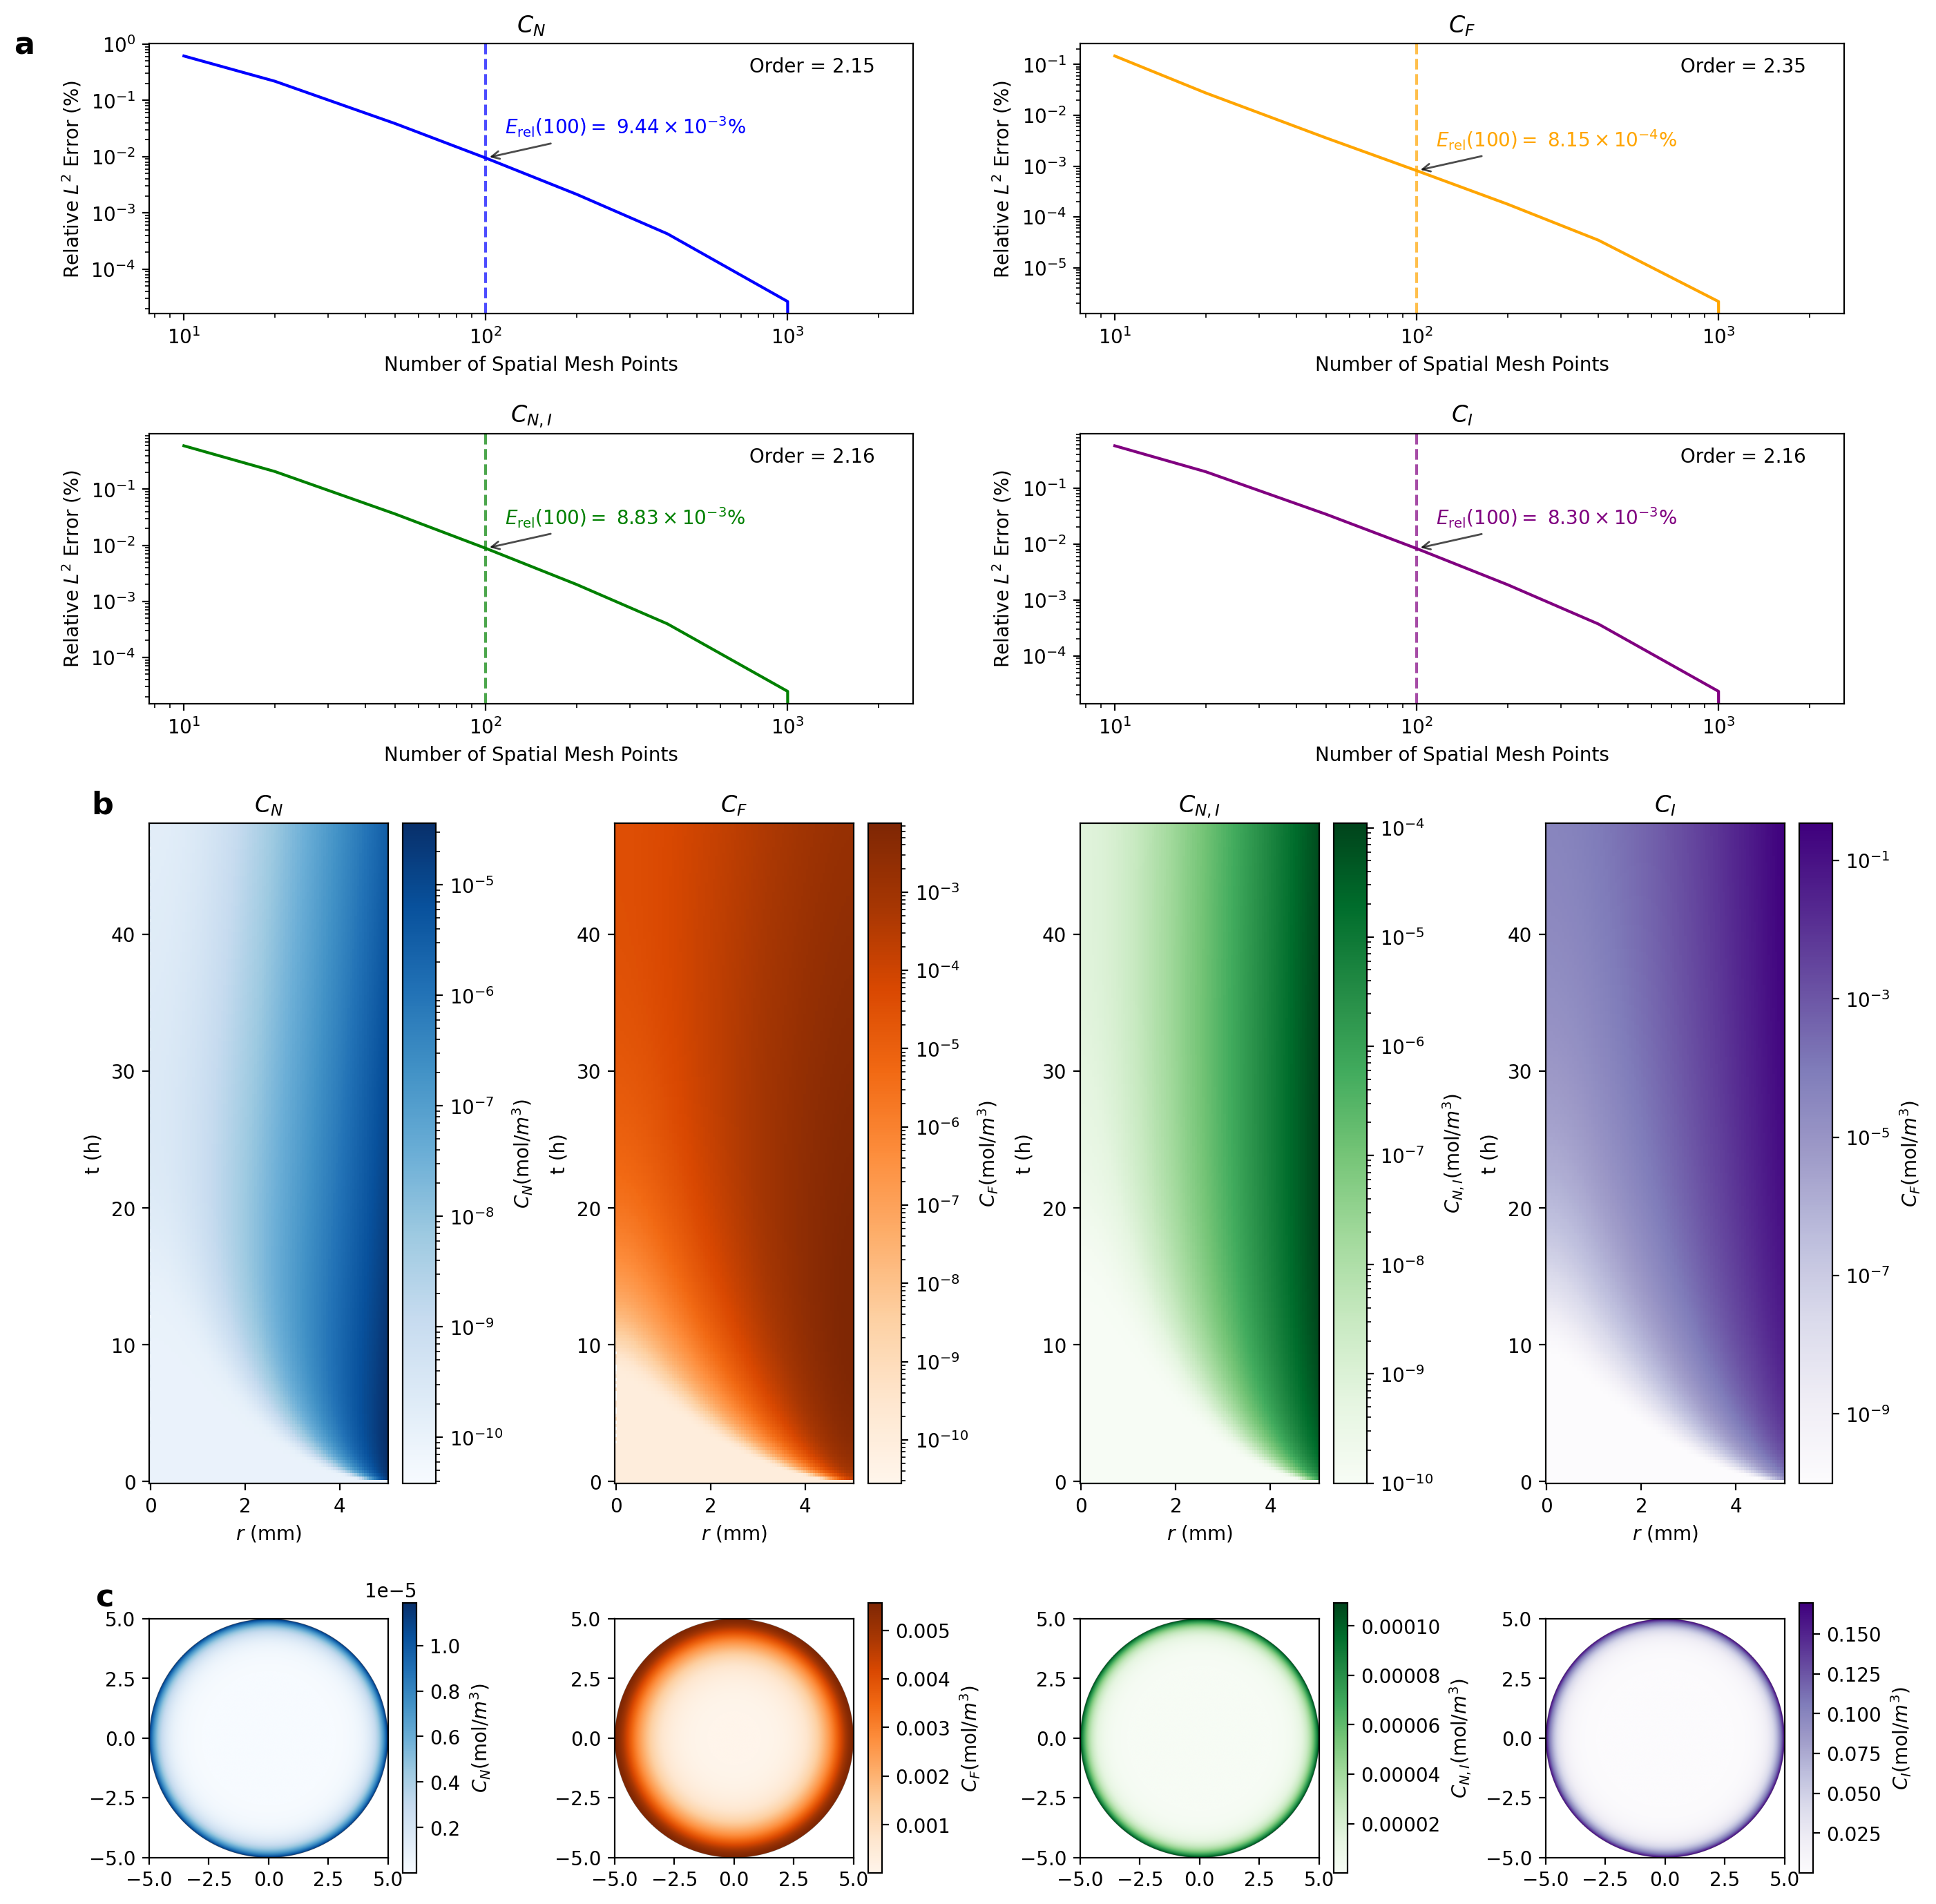

In [6]:
layout = [["A", "A", "B", "B"],
          ["C", "C", "D", "D"],
          ["E", "F", "G", "H"],
          ["E", "F", "G", "H"],
          ["I", "J", "K", "L"]]
fig, ax = plt.subplot_mosaic(layout, figsize=(14, 14))

idx_100 = 3

err_100 = [
    C_N_errs[idx_100],
    C_F_errs[idx_100],
    C_NI_errs[idx_100],
    C_I_errs[idx_100],
]

R = 0.005
N = 2000
r_100 = np.linspace(0, R, 100)

x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)
X, Y = np.meshgrid(x, y)

R_grid = np.sqrt(X**2 + Y**2)

CN_2d = np.interp(R_grid, r_100, C_N_results[idx_100][100])
CN_2d[R_grid > R] = np.nan

CF_2d = np.interp(R_grid, r_100, C_F_results[idx_100][100])
CF_2d[R_grid > R] = np.nan

CNI_2d = np.interp(R_grid, r_100, C_NI_results[idx_100][100])
CNI_2d[R_grid > R] = np.nan

CI_2d = np.interp(R_grid, r_100, C_I_results[idx_100][100])
CI_2d[R_grid > R] = np.nan


plots = [
    (ax["A"], C_N_errs,  p_CN,  r"$C_N$",   err_100[0], "blue"),
    (ax["B"], C_F_errs,  p_CF,  r"$C_F$",   err_100[1], "orange"),
    (ax["C"], C_NI_errs, p_NI,  r"$C_{N,I}$", err_100[2], "green"),
    (ax["D"], C_I_errs,  p_I,   r"$C_I$",   err_100[3], "purple"),
]

for axis, errors, slope, title, error_100, color in plots:
    axis.loglog(N_r_vals, errors, color= color)
    axis.set_title(title)

    axis.annotate(
        rf"Order = {slope:.2f}",
        xy=(0.95, 0.95),
        xycoords="axes fraction",
        ha="right",
        va="top"
    )

    axis.axvline(
        100,
        linestyle="--",
        alpha=0.7,
        color = color
    )

    axis.annotate(
        rf"$E_{{\mathrm{{rel}}}}(100) = $ {format_sci(error_100, 2)}%",
        xy=(100, error_100),
        xytext=(10, 10),
        textcoords="offset points",
        ha="left",
        va="bottom",
        arrowprops=dict(arrowstyle="->", alpha=0.7),
        color= color
    )
    axis.set_xlabel("Number of Spatial Mesh Points")
    axis.set_ylabel(r"Relative $L^2$ Error (%)")
ax["A"].text(-0.15, 1.05, "a", transform=ax["A"].transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

t_h = t / 3600
epsilon = 1e-10
r_100 *=1000

CN_im = ax["E"].pcolormesh(r_100, t_h, C_N_results[idx_100] + epsilon, cmap="Blues", norm= "log")
ax["E"].set_xlabel(r"$r$ (mm)")
ax["E"].set_ylabel(r"t (h)")
ax["E"].set_title(r"$C_N$")
cbar_err = fig.colorbar(CN_im)
cbar_err.set_label(r"$C_N (\text{mol}/m^3)$")

CF_im = ax["F"].pcolormesh(r_100, t_h, C_F_results[idx_100] + epsilon, cmap="Oranges", norm= "log")
ax["F"].set_xlabel(r"$r$ (mm)")
ax["F"].set_ylabel(r"t (h)")
ax["F"].set_title(r"$C_F$")
cbar_err = fig.colorbar(CF_im)
cbar_err.set_label(r"$C_F (\text{mol}/m^3)$")

CNI_im = ax["G"].pcolormesh(r_100, t_h, C_NI_results[idx_100] + epsilon, cmap="Greens", norm= "log")
ax["G"].set_xlabel(r"$r$ (mm)")
ax["G"].set_ylabel(r"t (h)")
ax["G"].set_title(r"$C_{N,I}$")
cbar_err = fig.colorbar(CNI_im)
cbar_err.set_label(r"$C_{N,I} (\text{mol}/m^3)$")

CI_im = ax["H"].pcolormesh(r_100, t_h, C_I_results[idx_100] + epsilon, cmap="Purples", norm= "log")
ax["H"].set_xlabel(r"$r$ (mm)")
ax["H"].set_ylabel(r"t (h)")
ax["H"].set_title(r"$C_I$")
cbar_err = fig.colorbar(CI_im)
cbar_err.set_label(r"$C_F (\text{mol}/m^3)$")

ax["E"].text(-0.15, 1.05, "b", transform=ax["E"].transAxes, fontsize=16, fontweight='bold', va='top', ha='right')


CN_im = ax["I"].imshow(
    CN_2d,
    extent=[-R*1000, R*1000, -R*1000, R*1000],
    origin="lower",
    cmap="Blues"
)
cbar_err = fig.colorbar(CN_im)
cbar_err.set_label(r"$C_{N} (\text{mol}/m^3)$")


CF_im = ax["J"].imshow(
    CF_2d,
    extent=[-R*1000, R*1000, -R*1000, R*1000],
    origin="lower",
    cmap="Oranges"
)
cbar_err = fig.colorbar(CF_im)
cbar_err.set_label(r"$C_{F} (\text{mol}/m^3)$")


CNI_im = ax["K"].imshow(
    CNI_2d,
    extent=[-R*1000, R*1000, -R*1000, R*1000],
    origin="lower",
    cmap="Greens"
)
cbar_err = fig.colorbar(CNI_im)
cbar_err.set_label(r"$C_{N,I} (\text{mol}/m^3)$")


CI_im = ax["L"].imshow(
    CI_2d,
    extent=[-R*1000, R*1000, -R*1000, R*1000],
    origin="lower",
    cmap="Purples"
)
cbar_err = fig.colorbar(CI_im)
cbar_err.set_label(r"$C_{I} (\text{mol}/m^3)$")

ticks = [-5.0, -2.5, 0, 2.5, 5.0]

for label in ["I", "J", "K", "L"]:
    ax[label].set_xticks(ticks)
    ax[label].set_yticks(ticks)


ax["I"].text(-0.15, 1.15, "c", transform=ax["I"].transAxes, fontsize=16, fontweight='bold', va='top', ha='right')




plt.tight_layout()


In [7]:
def J(phys, params):
    P_N = P_N_from_dim(phys)
    D_N = D_N_from_dim(phys)
    alpha = alpha_from_dim(phys)
    r, t, _, _, _, CI = forward_solver(P_N, D_N, alpha, phys, params)
    res = np.trapezoid(CI * (r ** 2), r, axis=1)
    integral = np.trapezoid(res, t) * 4 * np.pi
    return integral

In [8]:
phys_point_1_B_U = PhysicsConstants(P0= 1e-10, d_pore= 80e-9, xi_ECM= 25e-9, d_opt= 48e-9, sigma_d= 10e-9, d_val_m= 42.5e-9, k_rel=6.06455874e-05)
phys_point_1_B_D = PhysicsConstants(P0= 1e-10, d_pore= 80e-9, xi_ECM= 25e-9, d_opt= 48e-9, sigma_d= 10e-9, d_val_m= 20.00e-9, k_rel= 4.2e-3)

phys_point_2_B_U = PhysicsConstants(P0= 1e-10, d_pore= 80e-9, xi_ECM= 25e-9, d_opt= 55e-9, sigma_d= 10e-9, d_val_m= 45.00e-9, k_rel= 5.9e-5)
phys_point_2_B_D = PhysicsConstants(P0= 1e-10, d_pore= 80e-9, xi_ECM= 25e-9, d_opt= 55e-9, sigma_d= 10e-9, d_val_m= 20.00e-9, k_rel= 9.62772825e-03)

phys_point_3_B_U = PhysicsConstants(P0= 1e-10, d_pore= 80e-9, xi_ECM= 25e-9, d_opt= 61e-9, sigma_d= 10e-9, d_val_m= 50.00e-9, k_rel= 5.8e-5)
phys_point_3_B_D = PhysicsConstants(P0= 1e-10, d_pore= 80e-9, xi_ECM= 25e-9, d_opt= 61e-9, sigma_d= 10e-9, d_val_m= 20.00e-9, k_rel= 4.93806708e-03)

params_1 = SimulationParameters(Nr= 100)
params_2 = SimulationParameters(Nr= 200)
params_3 = SimulationParameters(Nr= 400)
params_4 = SimulationParameters(Nr= 800)
param_list = [params_1, params_2, params_3, params_4]
d_opt_vals = [48e-9, 55e-9, 61e-9]

In [9]:
results = {
    "before": {
        "B_U": [J(phys_point_1_B_U, param) for param in param_list],
        "B_D": [J(phys_point_1_B_D, param) for param in param_list],
    },
    "during" : {
        "B_U": [J(phys_point_2_B_U, param) for param in param_list],
        "B_D": [J(phys_point_2_B_D, param) for param in param_list],
    },
    "after" : {
        "B_U": [J(phys_point_3_B_U, param) for param in param_list],
        "B_D": [J(phys_point_3_B_D, param) for param in param_list],
    }
}

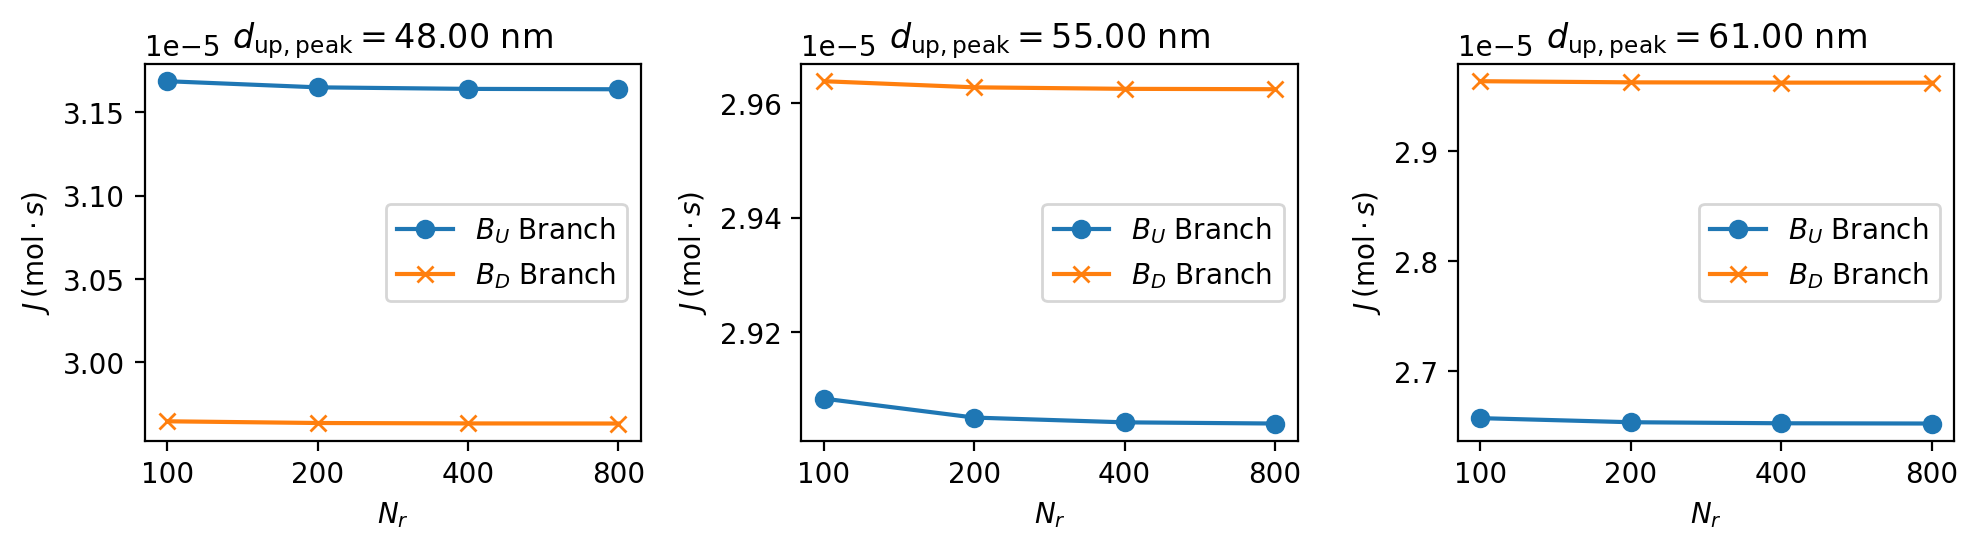

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
for i, (key, value) in enumerate(results.items()):
    ax[i].semilogx([param.Nr for param in param_list], value["B_U"], label=r"$B_U$ Branch", marker="o")
    ax[i].semilogx([param.Nr for param in param_list], value["B_D"], label=r"$B_D$ Branch", marker="x")
    ax[i].set_title(fr"$d_{{\mathrm{{up,peak}}}} = {d_opt_vals[i]*1e9:.2f}$ nm")
    ax[i].set_ylabel(r"$J \, (\mathrm{mol} \cdot s)$")
    ax[i].set_xlabel("$N_r$")
    
    ax[i].legend()
for a in ax:
    a.minorticks_off()
    a.set_xticks([100, 200, 400, 800])
    a.set_xticklabels([100, 200, 400, 800])
fig.tight_layout()


In [11]:
phy = PhysicsConstants()
params = SimulationParameters()
DN = D_N_from_dim(phy)
PN = P_N_from_dim(phy)
alpha1 = alpha_from_dim(phy)
r, t, CN, CF, C_IN, CI = forward_solver(PN, DN, alpha1, phy, params)

In [12]:
def format_scientific(string):
    if "e" in string:
        base, exponent = string.split("e")
        return f"{float(base)} \\times 10^{{{int(exponent)}}} \mathrm{{mol / m^3}}"

In [13]:
print("C_N")
print(format_scientific(f"{CN.max():.4e}"))
print(format_scientific(f"{CN.min():.4e}"))
print("C_F")
print(format_scientific(f"{CF.max():.4e}"))
print(format_scientific(f"{CF.min():.4e}"))
print("C_IN")
print(format_scientific(f"{C_IN.max():.4e}"))
print(format_scientific(f"{C_IN.min():.4e}"))
print("C_I")
print(format_scientific(f"{CI.max():.4e}"))
print(format_scientific(f"{CI.min():.4e}"))

C_N
3.6046 \times 10^{-5} \mathrm{mol / m^3}
-6.1544 \times 10^{-11} \mathrm{mol / m^3}
C_F
7.5622 \times 10^{-3} \mathrm{mol / m^3}
-1.2502 \times 10^{-9} \mathrm{mol / m^3}
C_IN
1.0988 \times 10^{-4} \mathrm{mol / m^3}
-2.298 \times 10^{-13} \mathrm{mol / m^3}
C_I
3.4351 \times 10^{-1} \mathrm{mol / m^3}
-6.3255 \times 10^{-13} \mathrm{mol / m^3}


In [14]:
residual = mass_balance_residual(r, t, CN, CF, C_IN, CI, PN, DN, alpha1, phy, params)
print("Mass balance residual")
print(format_scientific(f"{np.abs(residual['relative_error']).max():.4e}"))
print(format_scientific(f"{np.abs(residual['relative_error']).min():.4e}"))

Mass balance residual
5.4418 \times 10^{-5} \mathrm{mol / m^3}
0.0 \times 10^{0} \mathrm{mol / m^3}
